# Ligand-Pocket QGNN: Quantum vs Classical Comparison

Comparison of Quantum and Classical GNN models for ligand-pocket binding classification.

**Architecture:**
- Ligand: Graph Neural Network → Latent Vector
- Pocket: MLP → Latent Vector
- Interaction: Quantum Circuit or Classical MLP → Binding Probability

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score
)
from tqdm import tqdm
import pandas as pd

from hardware_optimizer import setup_environment
from data import LigandPocketDataProcessor, LigandPocketDataset, collate_fn
from model import LigandPocketQGNN

## 1. Auto-Detect Hardware & Configure

In [ ]:
# Automatic hardware detection and optimization
hw_info, hw_config = setup_environment()

# Apply hardware-optimized configuration
DEVICE = hw_info['device']
BATCH_SIZE = hw_config['batch_size']
NUM_WORKERS = hw_config['num_workers']
PREFETCH = hw_config['prefetch_factor']
PIN_MEMORY = hw_config['pin_memory']
QUANTUM_DEVICE = hw_config['quantum_device']

# Paths
DATA_DIR = "/Users/priyanshudey/Code/Qunatum copy/othercode/data"
SAVE_DIR = "./ligand_pocket_comparison_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Reproducibility
SEED = 42069
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# Model hyperparameters
HIDDEN_DIM = 64
N_QUBITS = 6
N_QLAYERS = 2

# Training hyperparameters
EPOCHS = 100
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 15

Resume = False  # Whether to resume training from checkpoint

print(f" Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Data workers: {NUM_WORKERS}")
print(f"  Quantum device: {QUANTUM_DEVICE}")

HARDWARE DETECTED
Platform:     Darwin
CPU:          Apple M4 Pro
CPU Vendor:   APPLE
CPU Cores:    12
Device:       Apple Metal Performance Shaders
Memory:       24.0 GB
Capability:   apple_m4_gpu
AUTO-OPTIMIZED CONFIGURATION
Batch Size:   1024
Workers:      10
Prefetch:     5
Pin Memory:   True
Quantum Dev:  lightning.qubit

✓ Configuration:
  Device: mps
  Batch size: 1024
  Data workers: 10
  Quantum device: lightning.qubit


## 2. Load Data

In [3]:
processor = LigandPocketDataProcessor(DATA_DIR, seed=SEED)
processor.load_data(max_samples= 50)
interactions = processor.get_dataset()

print(f"Total interactions: {len(interactions)}")

Searching for data in: /Users/priyanshudey/Code/Qunatum copy/othercode/data
Found 50 protein descriptor files


Loading Data: 100%|██████████| 50/50 [00:00<00:00, 323.10it/s]


Generating negative samples (target: 364)...


Generating Negatives: 100%|██████████| 364/364 [00:00<00:00, 1017139.68it/s]

Loaded 41 pockets, 364 ligands
Interactions: 364 positive, 364 negative
Total interactions: 728


## 3. Prepare Datasets

In [ ]:

#Split into train (80%) and temp (20%)
train_ints, temp_ints = train_test_split(interactions, test_size=0.2, random_state=SEED)

# Split temp into val (50%) and test (50%), giving final 10% val, 10% test
val_ints, test_ints = train_test_split(temp_ints, test_size=0.5, random_state=SEED)

# Create datasets
train_dataset = LigandPocketDataset(processor, train_ints)
val_dataset = LigandPocketDataset(processor, val_ints)
test_dataset = LigandPocketDataset(processor, test_ints)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=PREFETCH if NUM_WORKERS > 0 else None
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=PREFETCH if NUM_WORKERS > 0 else None
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=PREFETCH if NUM_WORKERS > 0 else None
)

sample_ligand = processor.ligands[interactions[0].ligand_id]
sample_pocket = processor.pockets[interactions[0].pocket_id]
ligand_dim = sample_ligand.atom_features.shape[1]
pocket_dim = sample_pocket.to_vector().shape[0]

print(f" Dataset Split (80/10/10):")
print(f"  Train: {len(train_dataset):,} samples ({len(train_loader)} batches)")
print(f"  Val:   {len(val_dataset):,} samples ({len(val_loader)} batches)")
print(f"  Test:  {len(test_dataset):,} samples ({len(test_loader)} batches)")
print(f"\nInput dimensions:")
print(f"  Ligand: {ligand_dim}")
print(f"  Pocket: {pocket_dim}")

✓ Dataset Split (80/10/10):
  Train: 582 samples (1 batches)
  Val:   73 samples (1 batches)
  Test:  73 samples (1 batches)

Input dimensions:
  Ligand: 10
  Pocket: 19


## 4. Training Functions

In [ ]:
def train_epoch(model, optimizer, criterion, loader, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    
    for x, edge_idx, batch_vec, pocket, labels in tqdm(loader, desc='Train'):
        x, edge_idx, batch_vec, pocket, labels = (
            x.to(device), edge_idx.to(device), batch_vec.to(device),
            pocket.to(device), labels.to(device)
        )
        
        optimizer.zero_grad(set_to_none=True)
        outputs = model(x, edge_idx, batch_vec, pocket).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_preds_binary = (all_preds >= 0.5).astype(int)
    
    return {
        'loss': total_loss / len(all_labels),
        'accuracy': accuracy_score(all_labels, all_preds_binary)
    }


def evaluate(model, criterion, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    
    with torch.no_grad():
        for x, edge_idx, batch_vec, pocket, labels in tqdm(loader, desc='Val', leave=False):
            x, edge_idx, batch_vec, pocket, labels = (
                x.to(device), edge_idx.to(device), batch_vec.to(device),
                pocket.to(device), labels.to(device)
            )
            
            outputs = model(x, edge_idx, batch_vec, pocket).squeeze()
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * len(labels)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_preds_binary = (all_preds >= 0.5).astype(int)
    
    return {
        'loss': total_loss / len(all_labels),
        'accuracy': accuracy_score(all_labels, all_preds_binary),
        'auc': roc_auc_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds_binary, zero_division=0),
        'recall': recall_score(all_labels, all_preds_binary, zero_division=0),
        'f1': f1_score(all_labels, all_preds_binary, zero_division=0)
    }


def load_checkpoint(model, model_name, device):
    """Load model checkpoint and training history if they exist"""
    checkpoint_path = os.path.join(SAVE_DIR, f"{model_name}_best.pt")
    history_path = os.path.join(SAVE_DIR, f"{model_name}_history.json")
    
    start_epoch = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 
               'val_auc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}
    best_val_auc = 0.0
    patience_counter = 0
    
    if os.path.exists(checkpoint_path) and os.path.exists(history_path):
        print(f"\n📂 Found existing checkpoint for {model_name}")
        
        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location=device)
        patience_counter = checkpoint.get('patience_counter', 0)
        
        # Check if patience is already exhausted
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"   ⚠️  Patience already exhausted ({patience_counter}/{EARLY_STOPPING_PATIENCE})!")
            print(f"   🔄 Restarting training from scratch with fresh model...\n")
            # Return without loading anything - fresh start
            return model, history, 0, 0.0, 0
        
        # Load model weights with strict=False to handle architecture changes
        incompatible_keys = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        
        # Print warnings if there are incompatible keys
        if incompatible_keys.missing_keys:
            print(f"   ⚠️  Missing keys in checkpoint: {incompatible_keys.missing_keys}")
        if incompatible_keys.unexpected_keys:
            print(f"   ⚠️  Unexpected keys in checkpoint (will be ignored): {incompatible_keys.unexpected_keys}")
        
        best_val_auc = checkpoint.get('best_auc', 0.0)
        
        # Load history
        with open(history_path, 'r') as f:
            history = json.load(f)
        
        start_epoch = len(history['train_loss'])
        
        print(f"   Resuming from epoch {start_epoch}")
        print(f"   Best validation AUC so far: {best_val_auc:.4f}")
        print(f"   Patience counter: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        print(f"   Continue training from here? The model will resume training.\n")
    else:
        print(f"\n🆕 No existing checkpoint found. Starting fresh training for {model_name}\n")
    
    return model, history, start_epoch, best_val_auc, patience_counter


def train_model(model, train_loader, val_loader, model_name, device, resume=True):
    print(f"\n{'='*70}\nTraining {model_name.upper()}\n{'='*70}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    if resume:
        model, history, start_epoch, best_val_auc, patience_counter = load_checkpoint(model, model_name, device)
    else:
        start_epoch = 0
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 
                   'val_auc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}
        best_val_auc = 0.0
        patience_counter = 0
    
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCELoss()
    
    start_time = datetime.now()
    
    for epoch in range(start_epoch, EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        train_metrics = train_epoch(model, optimizer, criterion, train_loader, device)
        val_metrics = evaluate(model, criterion, val_loader, device)
        scheduler.step(val_metrics['auc'])
        
        # Store all metrics properly
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])
        
        print(f"  Train: Loss={train_metrics['loss']:.4f}, Acc={train_metrics['accuracy']:.4f}")
        print(f"  Val:   Loss={val_metrics['loss']:.4f}, Acc={val_metrics['accuracy']:.4f}, "
              f"AUC={val_metrics['auc']:.4f}, F1={val_metrics['f1']:.4f}")
        
        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(), 
                'best_auc': best_val_auc,
                'epoch': epoch + 1,
                'patience_counter': patience_counter
            }, os.path.join(SAVE_DIR, f"{model_name}_best.pt"))
            print(f"  ✓ New best AUC: {best_val_auc:.4f}")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
            # Save current patience counter even when not improving
            torch.save({
                'model_state_dict': model.state_dict(), 
                'best_auc': best_val_auc,
                'epoch': epoch + 1,
                'patience_counter': patience_counter
            }, os.path.join(SAVE_DIR, f"{model_name}_best.pt"))
        
        # Save history after each epoch (allows resuming)
        with open(os.path.join(SAVE_DIR, f"{model_name}_history.json"), 'w') as f:
            json.dump(history, f, indent=2)
        
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    print(f"\nComplete: {(datetime.now() - start_time).total_seconds()/60:.2f} min, Best AUC: {best_val_auc:.4f}")
    return history, best_val_auc

## 5. Train Quantum Model

In [6]:
quantum_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim, pocket_in_dim=pocket_dim, hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS, n_qlayers=N_QLAYERS, use_quantum=True, quantum_device=QUANTUM_DEVICE
)

quantum_history, quantum_best_auc = train_model(quantum_model, train_loader, val_loader, "quantum", DEVICE)

✓ Parallel Quantum layer created
  Qubits: 6, Layers: 2, Device: lightning.qubit
  🚀 Using 12 worker threads for parallel evaluation

Training QUANTUM
Parameters: 10,694

📂 Found existing checkpoint for quantum


RuntimeError: Error(s) in loading state_dict for LigandPocketQGNN:
	Unexpected key(s) in state_dict: "interaction._weights". 

## 6. Train Classical Model

In [ ]:
classical_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim, pocket_in_dim=pocket_dim, hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS, n_qlayers=N_QLAYERS, use_quantum=False
)

classical_history, classical_best_auc = train_model(classical_model, train_loader, val_loader, "classical", DEVICE)


Training CLASSICAL
Parameters: 11,207

Epoch 1/100


Train: 100%|██████████| 1/1 [00:00<00:00, 14.04it/s]


  Train: Loss=0.7664, Acc=0.4845
  Val:   Loss=0.6859, Acc=0.5753, AUC=0.5622, F1=0.0000
   New best AUC: 0.5622

Epoch 2/100


Train: 100%|██████████| 1/1 [00:00<00:00, 25.22it/s]


  Train: Loss=0.6970, Acc=0.5000
  Val:   Loss=0.6888, Acc=0.5753, AUC=0.4543, F1=0.0000
  Patience: 1/15

Epoch 3/100


...

  Train: Loss=0.6890, Acc=0.5498
  Val:   Loss=0.6929, Acc=0.5205, AUC=0.5207, F1=0.5977
  Patience: 13/15

Epoch 27/100


Train: 100%|██████████| 1/1 [00:00<00:00, 28.14it/s]


  Train: Loss=0.6889, Acc=0.5498
  Val:   Loss=0.6929, Acc=0.5205, AUC=0.5207, F1=0.5977
  Patience: 14/15

Epoch 28/100


Train: 100%|██████████| 1/1 [00:00<00:00, 26.17it/s]


  Train: Loss=0.6888, Acc=0.5498
  Val:   Loss=0.6929, Acc=0.5205, AUC=0.5188, F1=0.5977
  Patience: 15/15
Early stopping at epoch 28

Complete: 0.02 min, Best AUC: 0.6071


## 7. Results

In [ ]:
print("FINAL COMPARISON")
print(f"Quantum:   AUC = {quantum_best_auc:.4f}")
print(f"Classical: AUC = {classical_best_auc:.4f}")
diff = (quantum_best_auc - classical_best_auc) * 100
print(f"Difference: {diff:+.2f}% {'(quantum better)' if diff > 0 else '(classical better)'}")

# Detailed metrics
q_idx, c_idx = np.argmax(quantum_history['val_auc']), np.argmax(classical_history['val_auc'])
results = pd.DataFrame({
    'Model': ['Quantum', 'Classical'],
    'Epoch': [q_idx + 1, c_idx + 1],
    'Loss': [quantum_history['val_loss'][q_idx], classical_history['val_loss'][c_idx]],
    'Acc': [quantum_history['val_acc'][q_idx], classical_history['val_acc'][c_idx]],
    'AUC': [quantum_best_auc, classical_best_auc],
    'Prec': [quantum_history['val_precision'][q_idx], classical_history['val_precision'][c_idx]],
    'Rec': [quantum_history['val_recall'][q_idx], classical_history['val_recall'][c_idx]],
    'F1': [quantum_history['val_f1'][q_idx], classical_history['val_f1'][c_idx]]
})
print("\n" + results.to_string(index=False))
results.to_csv(os.path.join(SAVE_DIR, 'comparison_results.csv'), index=False)

FINAL COMPARISON
Quantum:   AUC = 0.6805
Classical: AUC = 0.6071
Difference: +7.33% (quantum better)

    Model  Epoch     Loss  Acc      AUC     Prec      Rec       F1
  Quantum      3 1.780227 None 0.680492 0.470588 0.774194 0.585366
Classical     13 0.697622 None 0.607143 0.402985 0.870968 0.551020


## 8. Visualization

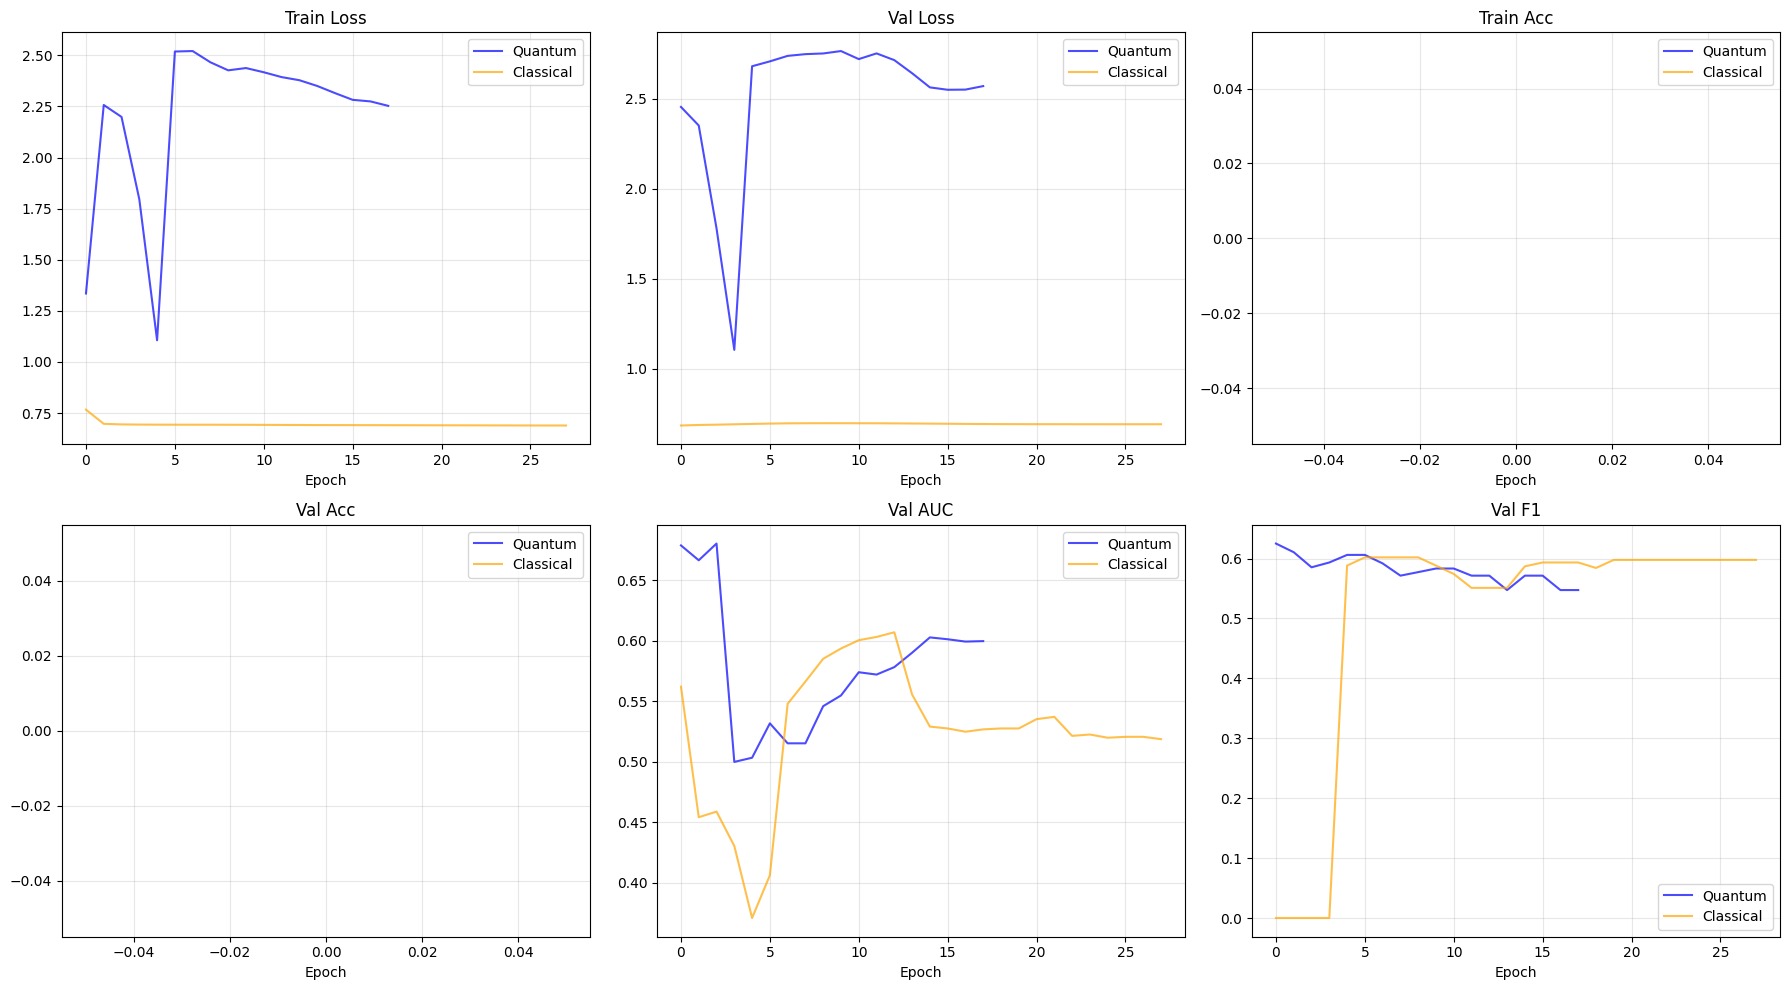


Plots saved to ./ligand_pocket_comparison_results/comparison_plots.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [('train_loss', 'Train Loss'), ('val_loss', 'Val Loss'), 
           ('train_acc', 'Train Acc'), ('val_acc', 'Val Acc'),
           ('val_auc', 'Val AUC'), ('val_f1', 'Val F1')]

for idx, (key, title) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    ax.plot(quantum_history[key], label='Quantum', color='blue', alpha=0.7)
    ax.plot(classical_history[key], label='Classical', color='orange', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'comparison_plots.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\nPlots saved to {SAVE_DIR}/comparison_plots.png")

## 9. Test Set Evaluation

Evaluate both models on the held-out 10% test set.

In [ ]:
def test_model(model, test_loader, model_name, checkpoint_path, device):
    # Load best model checkpoint and evaluate on test set"""
    print(f"Testing {model_name.upper()} on Test Set")
    
    # Load best checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    criterion = nn.BCELoss()
    all_preds, all_labels = [], []
    total_loss = 0.0
    
    with torch.no_grad():
        for x, edge_idx, batch_vec, pocket, labels in tqdm(test_loader, desc='Test'):
            x, edge_idx, batch_vec, pocket, labels = (
                x.to(device), edge_idx.to(device), batch_vec.to(device),
                pocket.to(device), labels.to(device)
            )
            
            outputs = model(x, edge_idx, batch_vec, pocket).squeeze()
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * len(labels)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_preds_binary = (all_preds >= 0.5).astype(int)
    
    test_metrics = {
        'loss': total_loss / len(all_labels),
        'accuracy': accuracy_score(all_labels, all_preds_binary),
        'auc': roc_auc_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds_binary, zero_division=0),
        'recall': recall_score(all_labels, all_preds_binary, zero_division=0),
        'f1': f1_score(all_labels, all_preds_binary, zero_division=0)
    }
    
    print(f"\nTest Set Results for {model_name}:")
    print(f"  Loss:      {test_metrics['loss']:.4f}")
    print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"  AUC:       {test_metrics['auc']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall:    {test_metrics['recall']:.4f}")
    print(f"  F1:        {test_metrics['f1']:.4f}")
        
    return test_metrics

# Test quantum model
quantum_test_metrics = test_model(
    quantum_model, 
    test_loader, 
    "Quantum",
    os.path.join(SAVE_DIR, "quantum_best.pt"),
    DEVICE
)

# Test classical model
classical_test_metrics = test_model(
    classical_model,
    test_loader,
    "Classical", 
    os.path.join(SAVE_DIR, "classical_best.pt"),
    DEVICE
)


Testing QUANTUM on Test Set


Test:   0%|          | 0/1 [00:00<?, ?it/s]/Users/priyanshudey/miniconda3/envs/quantum/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Test: 100%|██████████| 1/1 [00:07<00:00,  7.44s/it]



Test Set Results for Quantum:
  Loss:      1.5508
  Accuracy:  0.6438
  AUC:       0.5818
  Precision: 0.6538
  Recall:    0.8095
  F1:        0.7234

Testing CLASSICAL on Test Set


Test: 100%|██████████| 1/1 [00:00<00:00, 59.80it/s]


Test Set Results for Classical:
  Loss:      0.6865
  Accuracy:  0.6027
  AUC:       0.6544
  Precision: 0.5970
  Recall:    0.9524
  F1:        0.7339


In [ ]:
# Create test results comparison table
test_results = pd.DataFrame({
    'Model': ['Quantum', 'Classical'],
    'Test_Loss': [quantum_test_metrics['loss'], classical_test_metrics['loss']],
    'Test_Accuracy': [quantum_test_metrics['accuracy'], classical_test_metrics['accuracy']],
    'Test_AUC': [quantum_test_metrics['auc'], classical_test_metrics['auc']],
    'Test_Precision': [quantum_test_metrics['precision'], classical_test_metrics['precision']],
    'Test_Recall': [quantum_test_metrics['recall'], classical_test_metrics['recall']],
    'Test_F1': [quantum_test_metrics['f1'], classical_test_metrics['f1']]
})

print("TEST SET COMPARISON")
print(test_results.to_string(index=False))

# Save test results
test_results.to_csv(os.path.join(SAVE_DIR, 'test_results.csv'), index=False)

# Calculate improvement
auc_diff = (quantum_test_metrics['auc'] - classical_test_metrics['auc']) * 100
acc_diff = (quantum_test_metrics['accuracy'] - classical_test_metrics['accuracy']) * 100

print(f"\nTest Set Performance Difference:")
print(f"  AUC:      {auc_diff:+.2f}% {'(quantum better)' if auc_diff > 0 else '(classical better)'}")
print(f"  Accuracy: {acc_diff:+.2f}% {'(quantum better)' if acc_diff > 0 else '(classical better)'}")
print(f"\nTest results saved to {SAVE_DIR}/test_results.csv")


TEST SET COMPARISON
    Model  Test_Loss  Test_Accuracy  Test_AUC  Test_Precision  Test_Recall  Test_F1
  Quantum   1.550837       0.643836  0.581797        0.653846     0.809524 0.723404
Classical   0.686519       0.602740  0.654378        0.597015     0.952381 0.733945

Test Set Performance Difference:
  AUC:      -7.26% (classical better)
  Accuracy: +4.11% (quantum better)

Test results saved to ./ligand_pocket_comparison_results/test_results.csv
